<a href="https://colab.research.google.com/github/Bozhenashalginskaia/-----_--_----------------/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%98%D0%BD%D1%82%D0%B5%D1%80%D0%BF%D1%80%D0%B5%D1%82%D0%B8%D1%80%D1%83%D0%B5%D0%BC%D0%BE%D1%81%D1%82%D1%8C_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B5%D0%B9_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F_%D0%BF%D1%80%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D0%BF%D0%B0%D1%82%D0%BE%D0%BB%D0%BE%D0%B3%D0%B8%D0%B9_%D0%BC%D0%BE%D0%BB%D0%BE%D1%87%D0%BD%D0%BE%D0%B9_%D0%B6%D0%B5%D0%BB%D0%B5%D0%B7%D1%8B_%D0%BD%D0%B0_%D0%BE%D1%81%D0%BD%D0%BE%D0%B2%D0%B5_%D0%BA%D0%BB%D0%B8%D0%BD%D0%B8%D0%BA%D0%BE_%D0%B8%D0%BD%D1%81%D1%82%D1%80%D1%83%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D1%85_%D0%BF%D1%80%D0%B8%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D0%B2_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ (Feature Importance) ===
1. worst area: 0.1514
2. worst concave points: 0.1265
3. worst radius: 0.0935
4. worst perimeter: 0.0836
5. mean concave points: 0.0811

Вычисление SHAP-значений...


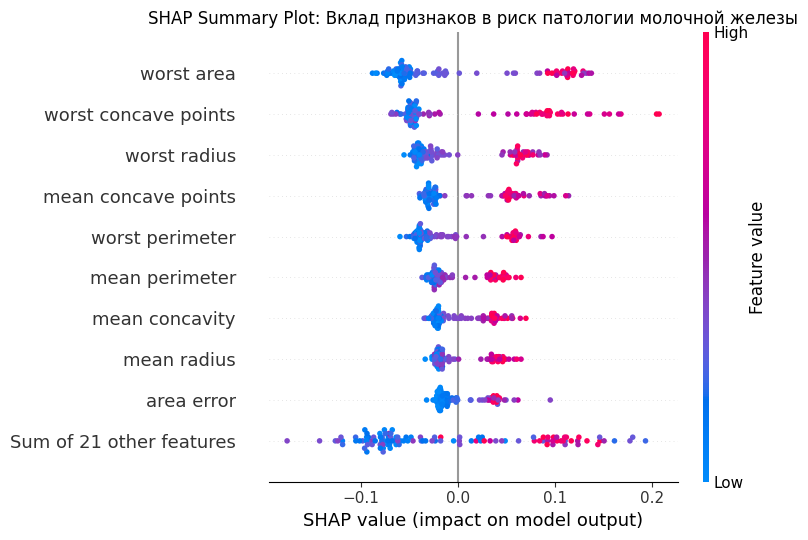

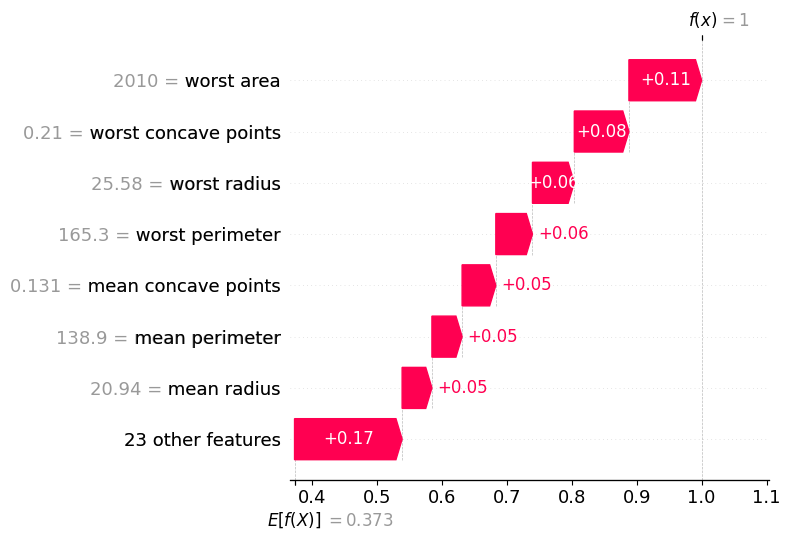


Графики сохранены! Объяснение сгенерировано для пациента №1 из тестовой выборки.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Загрузка данных
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Делаем 1 = Злокачественная опухоль (Malignant), 0 = Доброкачественная (Benign)
y = 1 - y

# Переименуем колонки для красивого вывода (по желанию, оставим англ. для биомаркеров)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Обучение модели
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Встроенная важность признаков (Feature Importance от Random Forest)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("=== ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ (Feature Importance) ===")
top_features = []
for f in range(5):
    feature_name = X.columns[indices[f]]
    importance_val = importances[indices[f]]
    top_features.append((feature_name, round(importance_val, 4)))
    print(f"{f+1}. {feature_name}: {round(importance_val, 4)}")

# 4. Вычисление SHAP values (Объяснимый ИИ)
print("\nВычисление SHAP-значений...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

# Примечание: для бинарной классификации берем значения для класса 1 (Патология)
if len(shap_values.shape) == 3:
    shap_vals_target = shap_values[:, :, 1]
else:
    shap_vals_target = shap_values

# 5. Построение Графика 1: SHAP Summary Plot (Глобальная важность)
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Вклад признаков в риск патологии молочной железы")
shap.plots.beeswarm(shap_vals_target, max_display=10, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300)
plt.show()

# 6. Построение Графика 2: SHAP Waterfall Plot (Локальное объяснение для 1 больного пациента)
# Найдем индекс первого больного пациента в тестовой выборке
sick_patient_idx = np.where(y_test == 1)[0][0]

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_vals_target[sick_patient_idx], max_display=8, show=False)
plt.tight_layout()
plt.savefig("shap_patient_explanation.png", dpi=300)
plt.show()

print(f"\nГрафики сохранены! Объяснение сгенерировано для пациента №{sick_patient_idx} из тестовой выборки.")